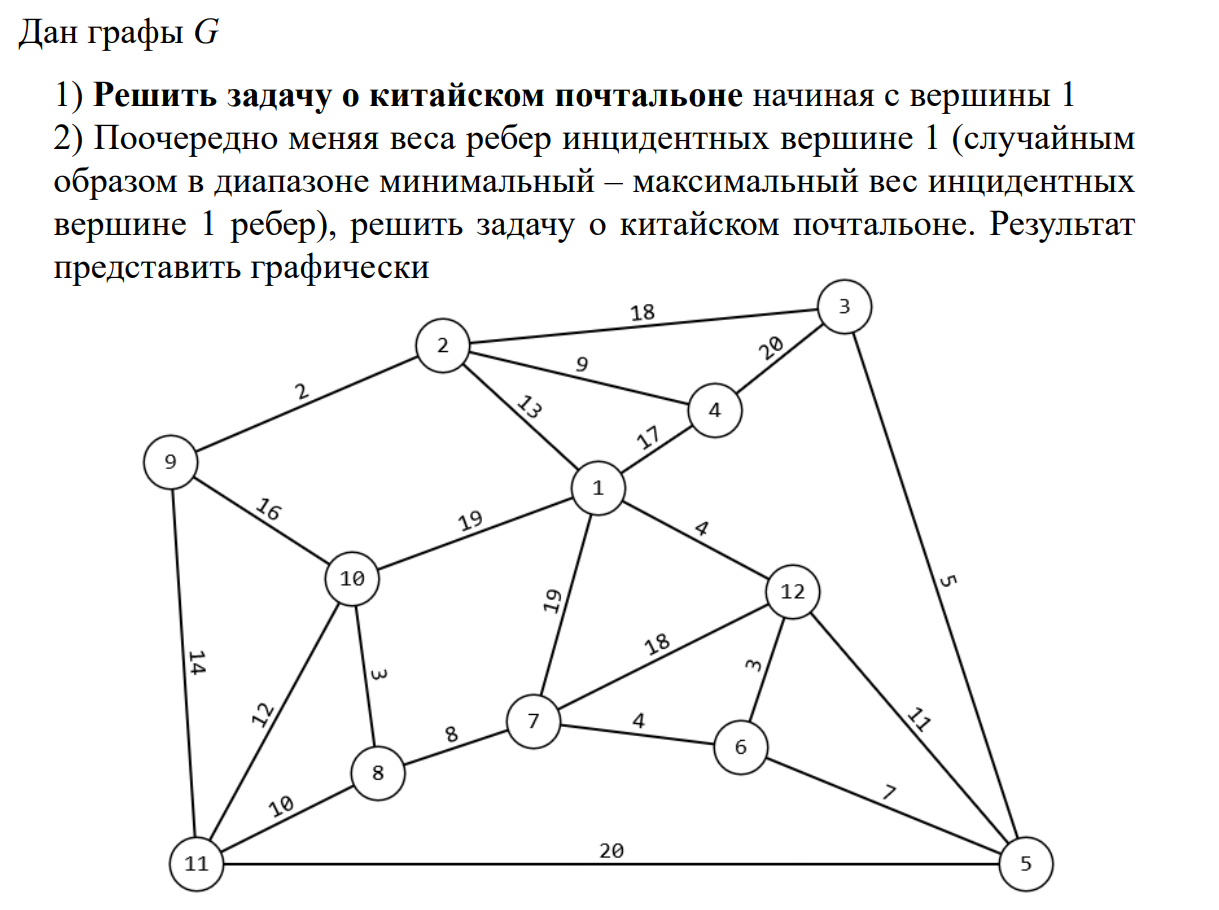

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import random

p = {1: [0, 0], 2: [-1.2, 1.5], 3: [1.8, 1.9], 4: [0.8, 0.7], 5: [2.8, -2.5], 6: [1.3, -1.6], 7: [-0.5, -1.2], 8: [-1.7, -2.1], 9: [-3, 0.5], 10: [-1.8, -0.4], 11: [-3.3, -2.8], 12: [1.4, -0.3]}
e = [(1, 2, 13), (1, 4, 17), (1, 10, 19), (1, 12, 4), (1, 7, 19), (2, 3, 18), (2, 4, 9), (2, 9, 2), (3, 4, 20), (3, 5, 5), (5, 6, 7), (5, 11, 20), (5, 12, 11), (6, 7, 4), (6, 12, 3), (7, 8, 8), (7, 12, 18), (8, 10, 3), (8, 11, 10), (9, 10, 16), (9, 11, 14), (10, 11, 12)]
g = nx.Graph()
g.add_weighted_edges_from(e)

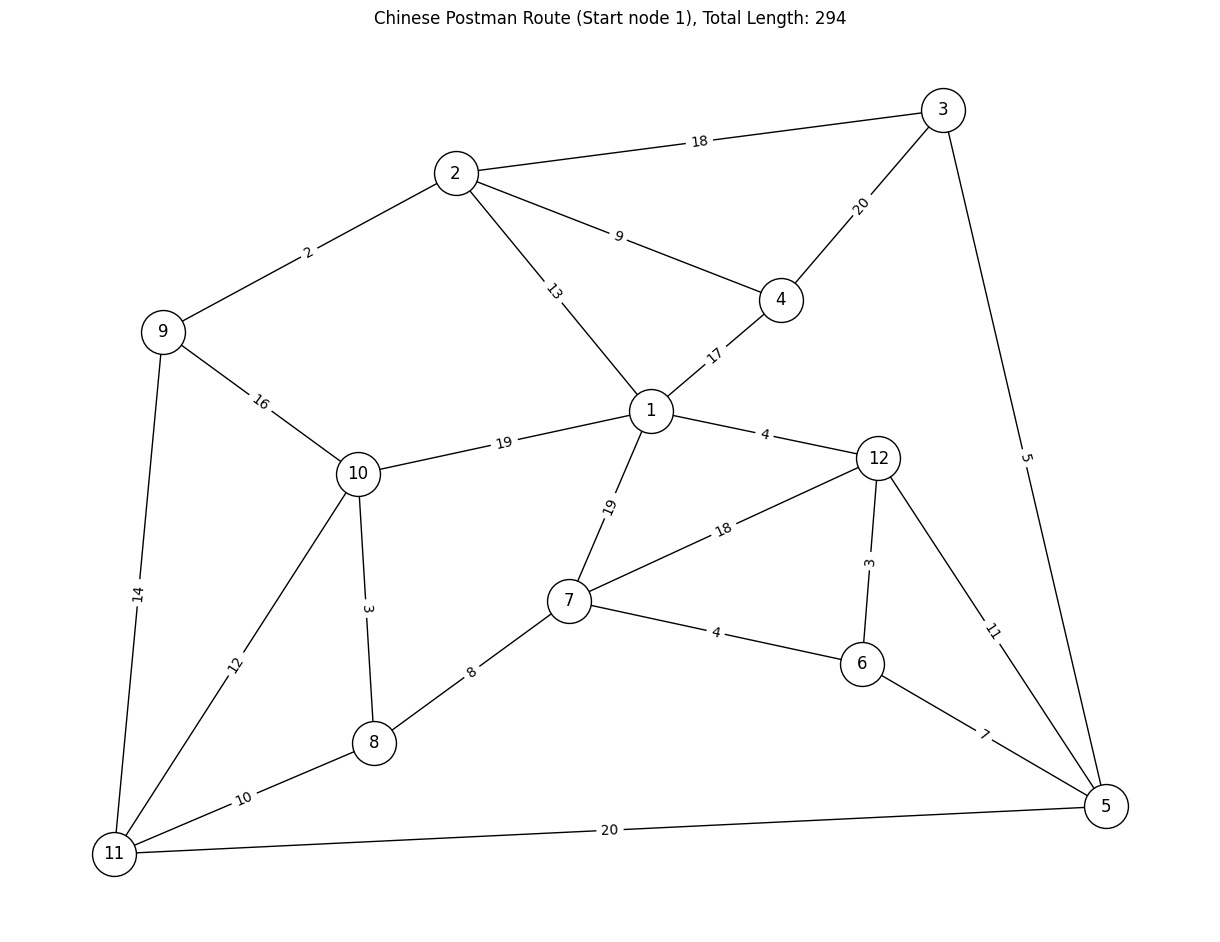

Path sequence: [1, 12, 7, 8, 11, 9, 2, 4, 2, 9, 10, 11, 5, 6, 7, 6, 12, 6, 5, 3, 5, 12, 1, 7, 8, 10, 1, 4, 3, 2, 1]


In [10]:
def slv(gr):
    o = [n for n, d in gr.degree() if d % 2 != 0]
    mg = nx.Graph()
    for i in range(len(o)):
        for j in range(i + 1, len(o)):
            d = nx.shortest_path_length(gr, o[i], o[j], weight='weight')
            mg.add_edge(o[i], o[j], weight=-d)
    m = nx.max_weight_matching(mg, True)
    ag = nx.MultiGraph(gr)
    for u, v in m:
        sp = nx.shortest_path(gr, u, v, weight='weight')
        for i in range(len(sp) - 1):
            ag.add_edge(sp[i], sp[i+1], weight=gr[sp[i]][sp[i+1]]['weight'])
    rt = list(nx.eulerian_circuit(ag, source=1))
    ln = sum(ag[u][v][k]['weight'] for u, v, k in ag.edges(keys=True))
    return rt, ln

rt, ln = slv(g)

plt.figure(figsize=(12, 9))
nx.draw(g, p, with_labels=True, node_color='white', edgecolors='black', node_size=1000, font_size=12)
nx.draw_networkx_edge_labels(g, p, edge_labels={(u, v): d['weight'] for u, v, d in g.edges(data=True)}, font_size=10)
plt.title(f"Chinese Postman Route (Start node 1), Total Length: {ln}")
plt.show()

print("Path sequence:", [1] + [step[1] for step in rt])

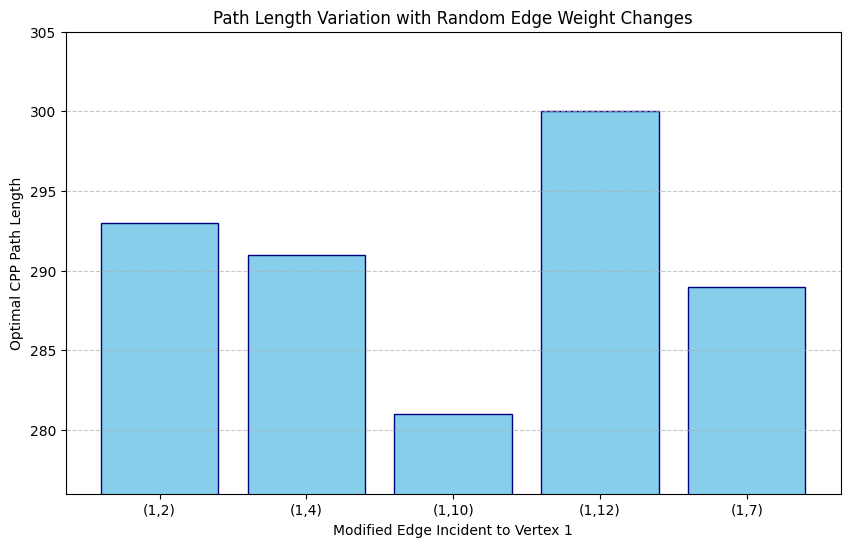

In [11]:
inc = list(g.edges(1))
ws = [g[u][v]['weight'] for u, v in inc]
mn, mx = min(ws), max(ws)
res = []

for u, v in inc:
    old = g[u][v]['weight']
    g[u][v]['weight'] = random.randint(mn, mx)
    _, l_i = slv(g)
    res.append(l_i)
    g[u][v]['weight'] = old

lbl = [f"({u},{v})" for u, v in inc]
plt.figure(figsize=(10, 6))
plt.bar(lbl, res, color='skyblue', edgecolor='navy')
plt.ylim(min(res) - 5, max(res) + 5)
plt.xlabel("Modified Edge Incident to Vertex 1")
plt.ylabel("Optimal CPP Path Length")
plt.title("Path Length Variation with Random Edge Weight Changes")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

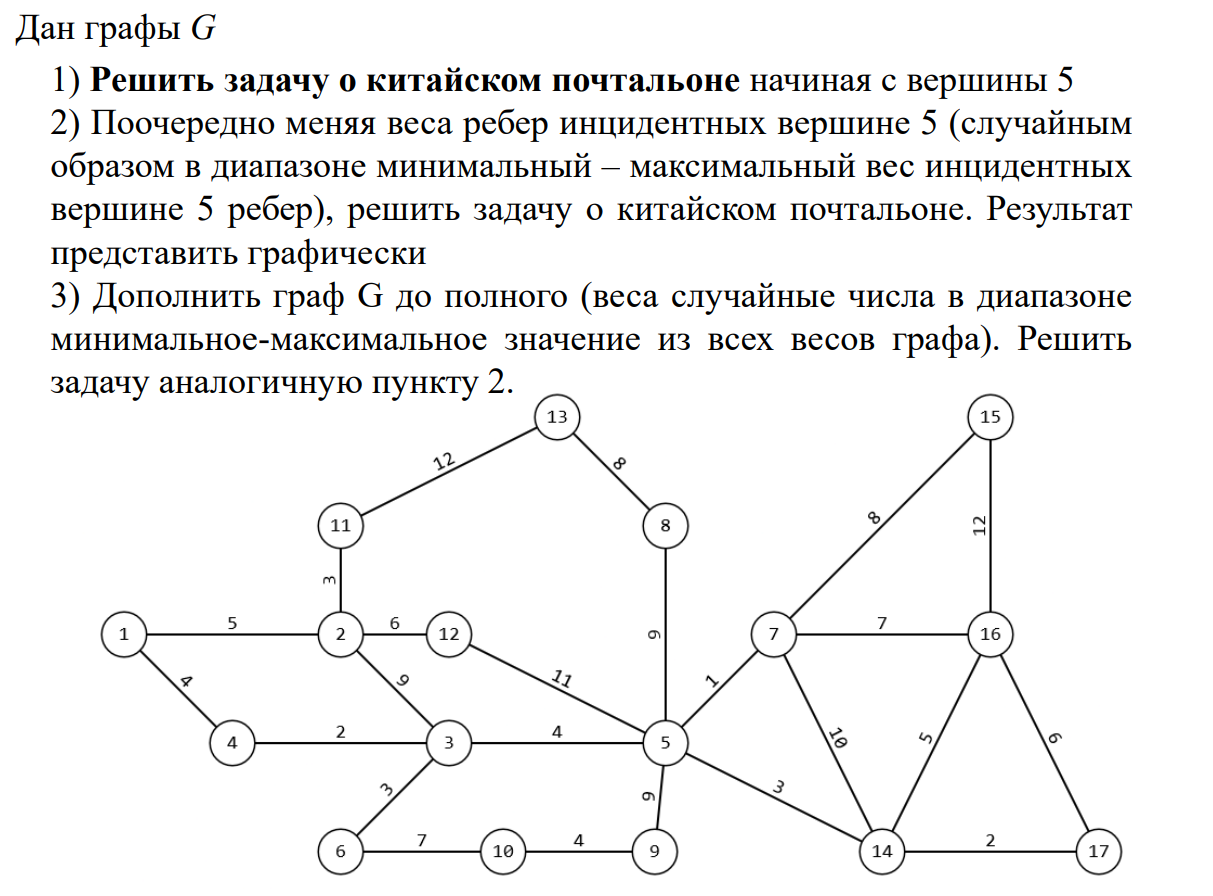

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import random

p = {1: [0, 2], 2: [2, 2], 3: [3, 1], 4: [1, 1], 5: [5, 1.5], 6: [2, 0], 7: [6, 2], 8: [5, 3], 9: [5, 0], 10: [3.5, 0], 11: [2, 3], 12: [3, 2], 13: [4, 4], 14: [7, 0.5], 15: [8, 4], 16: [8, 2], 17: [9, 0.5]}
e = [(1, 2, 5), (1, 4, 4), (2, 11, 3), (2, 12, 6), (2, 3, 9), (3, 4, 2), (3, 5, 4), (3, 6, 3), (5, 8, 9), (5, 12, 11), (5, 7, 1), (5, 14, 3), (5, 9, 6), (6, 10, 7), (7, 15, 8), (7, 16, 7), (7, 14, 10), (8, 13, 8), (9, 10, 4), (11, 13, 12), (14, 16, 5), (14, 17, 2), (15, 16, 12), (16, 17, 6)]
g = nx.Graph()
g.add_weighted_edges_from(e)

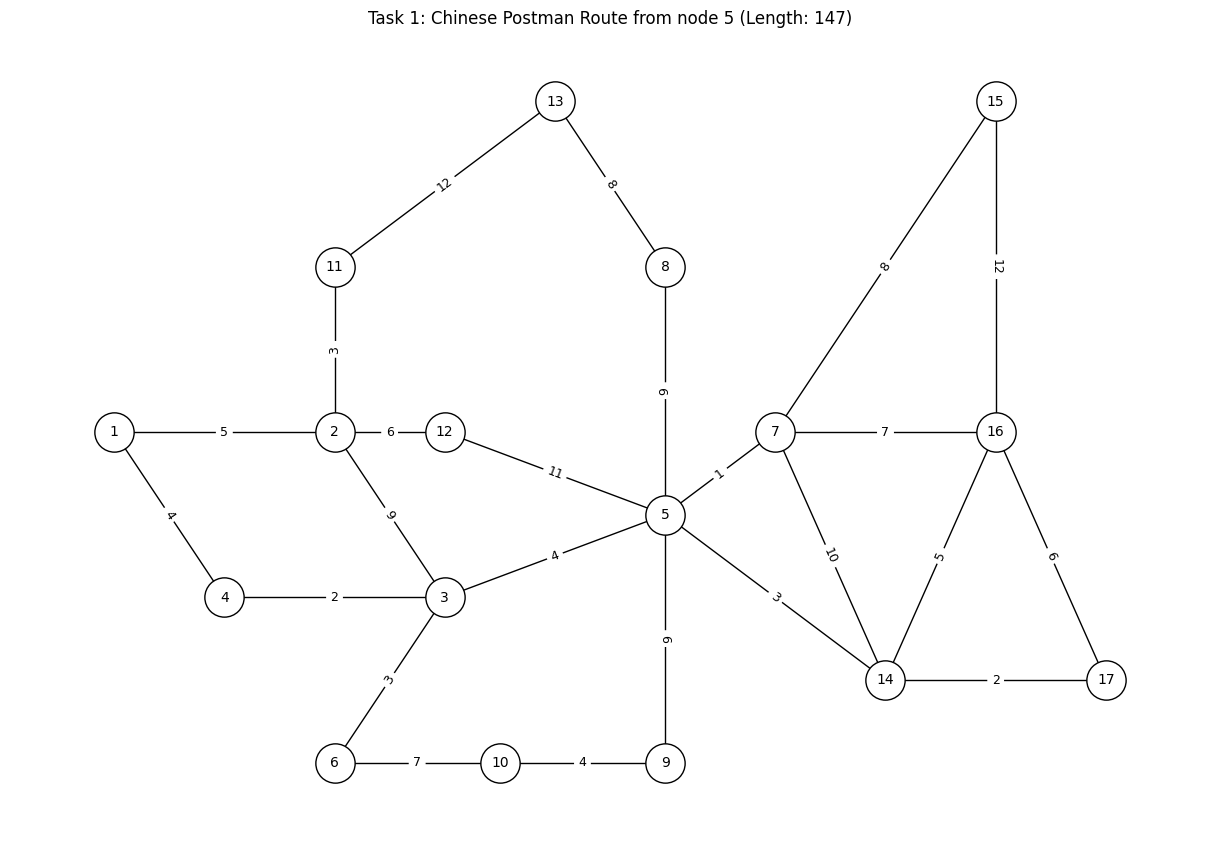

Path sequence: [5, 14, 17, 16, 14, 7, 16, 15, 7, 5, 9, 10, 6, 3, 5, 8, 13, 11, 2, 3, 4, 1, 2, 12, 5]


In [13]:
def slv(gr, s=5):
    o = [n for n, d in gr.degree() if d % 2 != 0]
    if not o:
        ag = nx.MultiGraph(gr)
    else:
        mg = nx.Graph()
        for i in range(len(o)):
            for j in range(i + 1, len(o)):
                d = nx.shortest_path_length(gr, o[i], o[j], weight='weight')
                mg.add_edge(o[i], o[j], weight=-d)
        m = nx.max_weight_matching(mg, True)
        ag = nx.MultiGraph(gr)
        for u, v in m:
            sp = nx.shortest_path(gr, u, v, weight='weight')
            for k in range(len(sp) - 1):
                ag.add_edge(sp[k], sp[k+1], weight=gr[sp[k]][sp[k+1]]['weight'])
    rt = list(nx.eulerian_circuit(ag, source=s))
    ln = sum(ag[u][v][k]['weight'] for u, v, k in ag.edges(keys=True))
    return rt, ln

rt, ln = slv(g)

plt.figure(figsize=(12, 8))
nx.draw(g, p, with_labels=True, node_color='white', edgecolors='black', node_size=800, font_size=10)
nx.draw_networkx_edge_labels(g, p, edge_labels={(u, v): d['weight'] for u, v, d in g.edges(data=True)}, font_size=9)
plt.title(f"Task 1: Chinese Postman Route from node 5 (Length: {ln})")
plt.show()

print("Path sequence:", [5] + [st[1] for st in rt])

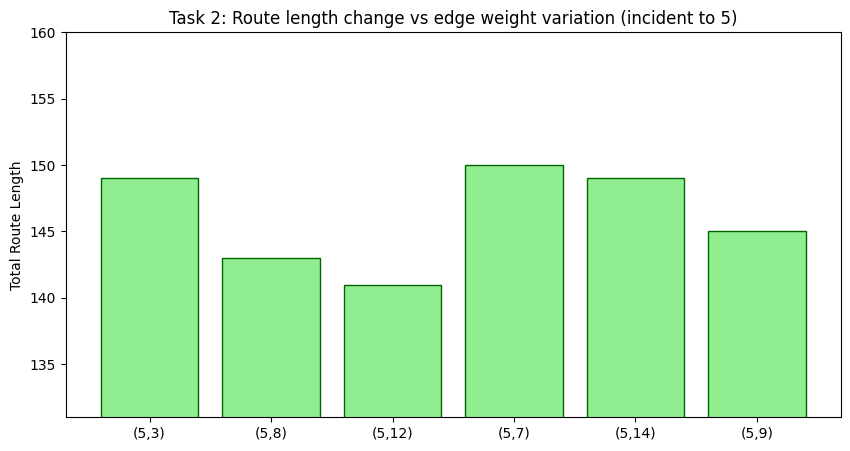

In [14]:
inc = list(g.edges(5))
ws = [g[u][v]['weight'] for u, v in inc]
mn, mx = min(ws), max(ws)
res = []

for u, v in inc:
    old = g[u][v]['weight']
    g[u][v]['weight'] = random.randint(mn, mx)
    _, l_i = slv(g)
    res.append(l_i)
    g[u][v]['weight'] = old

lbl = [f"({u},{v})" for u, v in inc]
plt.figure(figsize=(10, 5))
plt.bar(lbl, res, color='lightgreen', edgecolor='darkgreen')
plt.ylim(min(res) - 10, max(res) + 10)
plt.ylabel("Total Route Length")
plt.title("Task 2: Route length change vs edge weight variation (incident to 5)")
plt.show()

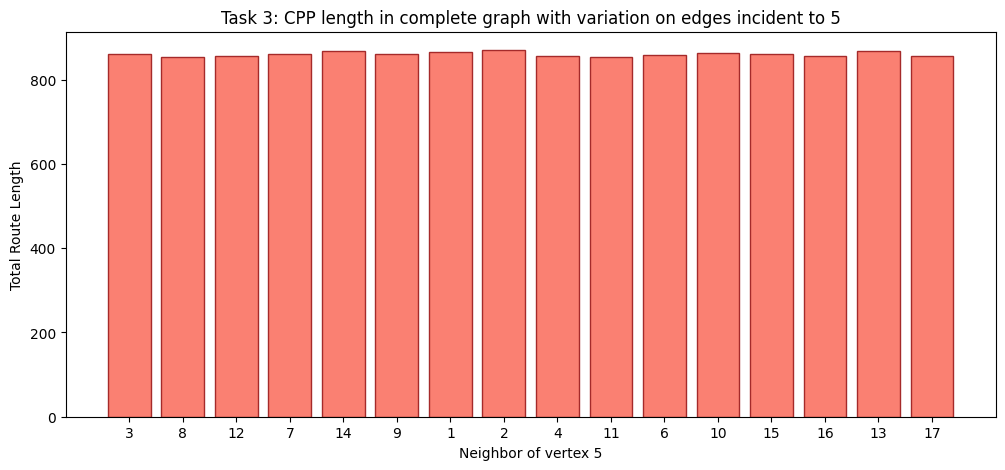

In [15]:
all_ws = [d['weight'] for u, v, d in g.edges(data=True)]
gmn, gmx = min(all_ws), max(all_ws)
nodes = list(g.nodes())
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        if not g.has_edge(nodes[i], nodes[j]):
            g.add_edge(nodes[i], nodes[j], weight=random.randint(gmn, gmx))

inc_c = list(g.edges(5))
ws_c = [g[u][v]['weight'] for u, v in inc_c]
cmn, cmx = min(ws_c), max(ws_c)
res_c = []

for u, v in inc_c:
    old = g[u][v]['weight']
    g[u][v]['weight'] = random.randint(cmn, cmx)
    _, l_i = slv(g)
    res_c.append(l_i)
    g[u][v]['weight'] = old

lbl_c = [f"{v}" for u, v in inc_c]
plt.figure(figsize=(12, 5))
plt.bar(lbl_c, res_c, color='salmon', edgecolor='brown')
plt.ylabel("Total Route Length")
plt.xlabel("Neighbor of vertex 5")
plt.title("Task 3: CPP length in complete graph with variation on edges incident to 5")
plt.show()